![Portada](img/Recurso-6.png)

# Investigacion de redes neuronales (CNN)

![Python](img/imgPython.jpg)

**Nombre:** Steven Cabascango Heredia 

**Fecha:** 12/04/2026

# Redes Neuronales Convolucionales (CNN): Una mirada completa

Cuando hablamos de inteligencia artificial aplicada a imágenes, casi inevitablemente terminamos hablando de las Redes Neuronales Convolucionales, o CNN por sus siglas en inglés (*Convolutional Neural Networks*). Estas arquitecturas se han convertido en uno de los pilares más importantes del aprendizaje profundo moderno, y entender cómo funcionan es esencial para cualquiera que quiera adentrarse en el mundo del machine learning.

Esta investigación recorre desde los conceptos más básicos hasta los más avanzados, con un ejemplo práctico al final para que puedas ver todo esto en acción.


## 1. Introducción: ¿por qué surgieron las CNN?

Para entender las CNN, hay que situarse en el contexto en el que aparecieron. Las redes neuronales tradicionales —las llamadas *fully connected* o totalmente conectadas— tienen un problema importante cuando se trabaja con imágenes: son computacionalmente muy costosas.

Imagina una imagen de 256x256 píxeles en escala de grises. Eso son 65.536 valores de entrada. Si los conectas a una capa oculta de solo 1.000 neuronas, ya tienes más de 65 millones de parámetros solo en esa primera capa. Y eso con una imagen relativamente pequeña.

Además, las redes totalmente conectadas no tienen en cuenta algo fundamental: **la estructura espacial de la imagen**. Para ese tipo de red, un píxel en la esquina superior izquierda no tiene ninguna relación especial con el que está justo al lado. Pero para nosotros, y para cualquier tarea visual que tenga sentido, la posición relativa de los píxeles importa mucho.

Fue precisamente para resolver estos dos problemas —eficiencia y localidad espacial— que surgieron las CNN. La idea central es sencilla pero poderosa: en lugar de conectar cada neurona con todos los píxeles de entrada, solo la conectamos con una pequeña región local. Y esa misma operación se repite a lo largo de toda la imagen, compartiendo los parámetros.

Esto reduce dramáticamente el número de parámetros y, al mismo tiempo, permite que la red aprenda características visuales de forma jerárquica: primero bordes simples, luego texturas, luego formas, y finalmente objetos completos.

## 2. Un poco de historia: de 1989 hasta hoy

La historia de las CNN no empieza en la era del deep learning moderno. Tiene raíces bastante más antiguas.

**1959 – Los experimentos de Hubel y Wiesel.** Todo comienza, en cierto modo, con un descubrimiento en neurobiología. David Hubel y Torsten Wiesel estudiaron cómo funcionaba la corteza visual de los gatos y descubrieron que ciertas neuronas respondían solo a estímulos en regiones específicas del campo visual, y que estas neuronas se organizaban de forma jerárquica. Este hallazgo les valió el Premio Nobel en 1981 y fue la inspiración biológica detrás de las CNN.

**1980 – Neocognitron.** Kunihiko Fukushima presentó el *Neocognitron*, una red neuronal que ya incorporaba capas de convolución y de submuestreo. No usaba backpropagation, pero sentó las bases conceptuales de lo que vendría después.

**1989–1998 – Yann LeCun y LeNet.** El gran salto llegó con Yann LeCun, quien combinó las ideas de Fukushima con el algoritmo de retropropagación. En 1998 presentó *LeNet-5*, una arquitectura que ya reconocía dígitos escritos a mano con una eficacia notable. Este modelo fue utilizado por varios bancos para leer cheques automáticamente.

**2000s – El invierno de las CNN.** Durante varios años, las CNN quedaron un poco en segundo plano. Las máquinas de vectores de soporte (SVM) dominaban el campo, y el hardware disponible no era suficiente para entrenar redes grandes.

**2012 – AlexNet cambia todo.** En 2012, Alex Krizhevsky, Ilya Sutskever y Geoffrey Hinton presentaron *AlexNet* en la competición ImageNet. Superaron al segundo lugar por un margen tan amplio que el campo entero viró su atención hacia las CNN. Esta red usaba GPUs para el entrenamiento y técnicas como *dropout* y *ReLU* que la hicieron más eficiente y poderosa.

**2014–2015 – VGG, GoogLeNet, ResNet.** La evolución fue rápida. *VGGNet* demostró que la profundidad importaba. *GoogLeNet* introdujo los módulos *Inception*. Y *ResNet* (2015) llegó con las conexiones residuales, permitiendo entrenar redes de más de 100 capas sin que el gradiente desapareciera.

**2017 en adelante.** Llegaron las arquitecturas más eficientes pensadas para dispositivos móviles, como *MobileNet* y *EfficientNet*. Y aunque los Transformers han ganado terreno en muchas tareas, las CNN siguen siendo ampliamente usadas y continúan evolucionando.

## 3. Arquitectura y componentes principales

Una CNN típica está formada por varios tipos de capas que se combinan de distintas formas. Aquí describimos cada una.



### 3.1 Capa de convolución (*Convolutional Layer*)

Es el corazón de toda la arquitectura. En esta capa se aplica una operación matemática llamada **convolución** entre la imagen de entrada y uno o varios **filtros** (también llamados *kernels*).

Un filtro es simplemente una pequeña matriz de números, por ejemplo de 3x3 o 5x5. Este filtro se va deslizando por toda la imagen y en cada posición realiza una multiplicación elemento a elemento con la región de la imagen que cubre, sumando todos los resultados. El número que se obtiene se coloca en la posición correspondiente del *mapa de características* (*feature map*).

Lo interesante es que los valores del filtro no los definimos nosotros: **los aprende la red durante el entrenamiento**. Así, la red aprende qué características son útiles para la tarea que tiene que resolver.

Algunos parámetros importantes en esta capa son:

- **Stride (paso):** cuántos píxeles se mueve el filtro en cada paso. Un stride de 1 mueve el filtro de un píxel a la vez; un stride de 2 lo mueve de dos en dos, reduciendo el tamaño del feature map.
- **Padding:** si se agregan bordes de ceros alrededor de la imagen para controlar el tamaño de salida. Con *same padding*, el feature map tiene el mismo tamaño que la entrada; con *valid padding*, se reduce.



### 3.2 Función de activación (*ReLU*)

Después de la convolución, normalmente se aplica una función de activación no lineal. La más común en las CNN modernas es **ReLU** (*Rectified Linear Unit*), que simplemente reemplaza todos los valores negativos por cero:

`f(x) = max(0, x)`

Parece algo trivial, pero esta no-linealidad es fundamental. Sin ella, apilar capas no tendría sentido porque la composición de funciones lineales sigue siendo lineal. ReLU además resuelve el problema del gradiente desvaneciente que tenían las funciones sigmoidales en redes profundas.



### 3.3 Capa de pooling (*Pooling Layer*)

Su objetivo es **reducir las dimensiones espaciales** del feature map. Esto se hace por varias razones: reduce la cantidad de parámetros, controla el overfitting y hace que la red sea más robusta a pequeñas variaciones en la posición de las características.

El tipo más usado es el **Max Pooling**: se toma una ventana (por ejemplo 2x2) y se queda con el valor máximo dentro de ella. Con un stride de 2, esto reduce las dimensiones a la mitad.

También existe el **Average Pooling**, que promedia los valores en lugar de tomar el máximo.



### 3.4 Capa de normalización por lotes (*Batch Normalization*)

Introducida en 2015, esta técnica normaliza las activaciones dentro de cada mini-batch durante el entrenamiento. Tiene dos efectos muy útiles: acelera el entrenamiento al estabilizar el proceso, y actúa como una forma de regularización reduciendo la necesidad de dropout en algunos casos.



### 3.5 Capas totalmente conectadas (*Fully Connected / Dense Layers*)

Al final de la red, después de varias capas de convolución y pooling, normalmente se añaden una o varias capas totalmente conectadas. En este punto, el feature map se *aplana* en un vector unidimensional, y estas capas realizan la clasificación final combinando todas las características aprendidas.

La última capa suele usar **softmax** para tareas de clasificación múltiple, que convierte los valores en probabilidades que suman 1.



### 3.6 Dropout

Es una técnica de regularización que durante el entrenamiento desactiva aleatoriamente un porcentaje de neuronas en cada paso. Esto obliga a la red a no depender demasiado de ninguna neurona en particular y mejora su capacidad de generalización.

## 4. ¿Cómo aprende una CNN? El proceso de entrenamiento

Entender el proceso de entrenamiento es clave para saber por qué las CNN funcionan tan bien.

### 4.1 Forward pass

Cuando una imagen entra a la red, pasa secuencialmente por todas las capas. Cada capa aplica sus operaciones y pasa el resultado a la siguiente, hasta llegar a la capa de salida que produce una predicción. Este recorrido de entrada a salida se llama *forward pass* o paso hacia adelante.

### 4.2 Función de pérdida (*Loss Function*)

Una vez que la red hace su predicción, necesitamos medir qué tan equivocada está. Para eso usamos una **función de pérdida** (*loss function*). En problemas de clasificación, la más común es la **entropía cruzada categórica** (*categorical cross-entropy*), que penaliza más los errores grandes y menos los pequeños.

### 4.3 Backpropagation y descenso del gradiente

Una vez calculada la pérdida, el algoritmo de **retropropagación** calcula el gradiente de esa pérdida con respecto a cada parámetro de la red (todos los valores de todos los filtros, pesos, etc.). Este gradiente indica en qué dirección y en qué medida se debe ajustar cada parámetro para reducir el error.

Luego, el **optimizador** usa esos gradientes para actualizar los parámetros. El optimizador más básico es el **Descenso del Gradiente Estocástico** (SGD), pero en la práctica suelen usarse variantes más sofisticadas como **Adam**, que adapta la tasa de aprendizaje de forma automática y converge más rápido.

### 4.4 Épocas e iteraciones

Todo este proceso (forward pass → calcular pérdida → backpropagation → actualizar pesos) se repite muchas veces. Cada vez que la red ve el conjunto de datos completo, se dice que ha completado una **época**. Normalmente se necesitan muchas épocas (decenas o cientos) para que la red converja a una solución satisfactoria.

### 4.5 Data Augmentation

Un truco muy útil para mejorar el rendimiento y prevenir el sobreajuste es la **aumentación de datos**. Consiste en aplicar transformaciones aleatorias a las imágenes durante el entrenamiento: rotar, voltear, recortar, cambiar el brillo, etc. De esta forma, la red ve versiones ligeramente diferentes de cada imagen en cada época y aprende a ser más robusta.


## 5. Aplicaciones principales

Las CNN se han aplicado con mucho éxito en una variedad de dominios. Estos son los más relevantes.



### 5.1 Visión por computadora

Es el campo donde nacieron y donde siguen siendo más utilizadas. Las aplicaciones aquí son enormes:

- **Clasificación de imágenes:** determinar qué objeto aparece en una imagen. Desde apps para identificar plantas hasta el diagnóstico médico.
- **Detección de objetos:** no solo clasificar, sino localizar objetos dentro de la imagen con cuadros delimitadores. Modelos como YOLO o Faster R-CNN son los más conocidos.
- **Segmentación semántica:** asignar una clase a cada píxel de la imagen. Se usa mucho en vehículos autónomos para separar carretera, peatones, señales, etc.
- **Reconocimiento facial:** sistemas de seguridad, desbloqueo de dispositivos, identificación en fotos.
- **Estimación de pose:** detectar la posición del cuerpo humano en tiempo real. Usado en deportes, videojuegos y fisioterapia.


### 5.2 Medicina y salud

Quizás el área donde el impacto es más significativo desde un punto de vista humano.

- Detección de tumores en radiografías, tomografías y resonancias magnéticas.
- Diagnóstico de retinopatía diabética a partir de imágenes del fondo de ojo.
- Clasificación de lesiones dermatológicas para detectar melanoma.
- Análisis histopatológico automatizado para identificar células cancerosas en biopsias.

En varios de estos casos, las CNN han demostrado un rendimiento comparable o incluso superior al de médicos especialistas.



### 5.3 Vehículos autónomos

Los coches autónomos dependen en gran medida de CNN para procesar en tiempo real las imágenes de cámaras y sensores. Necesitan identificar peatones, ciclistas, señales de tráfico, carriles y obstáculos en fracciones de segundo. Empresas como Tesla, Waymo y Mobileye han invertido enormemente en este campo.



### 5.4 Procesamiento de lenguaje y audio

Aunque los transformers dominan el NLP hoy en día, las CNN también se han usado con resultados sólidos en:

- Clasificación de texto (cuando se trata el texto como una secuencia y se aplican filtros 1D).
- Reconocimiento de voz, donde el audio se convierte en un espectrograma (una imagen) y se procesa con CNN.
- Clasificación de géneros musicales.



### 5.5 Industria y manufactura

En entornos industriales, las CNN permiten automatizar procesos de control de calidad visual. Una cámara industrial puede detectar defectos en piezas o productos en una línea de producción con mucha más velocidad y consistencia que un operario humano.



### 5.6 Agricultura

Se usan para detectar enfermedades en cultivos a partir de imágenes de drones o satélites, estimar el rendimiento de las cosechas, y clasificar frutas y verduras según su madurez o calidad.



### 5.7 Generación de imágenes

Las CNN también están en el corazón de muchas técnicas generativas, como las **Redes Generativas Adversariales (GANs)**, donde una CNN aprende a generar imágenes realistas, y la **transferencia de estilo neuronal**, que aplica el estilo artístico de una imagen a otra.

## 6. Ventajas y limitaciones

Como cualquier herramienta, las CNN tienen sus puntos fuertes y sus debilidades. Conocer ambos es importante para saber cuándo usarlas y cuándo no.

### Ventajas

- **Aprendizaje automático de características.** No hay que definir manualmente qué rasgos extraer de las imágenes; la red los aprende sola.
- **Eficiencia por peso compartido.** Los mismos filtros se aplican a toda la imagen, lo que reduce enormemente el número de parámetros en comparación con redes totalmente conectadas.
- **Robustez a la traslación.** Gracias al pooling y al peso compartido, la red puede reconocer un objeto aunque esté en distintas posiciones de la imagen.
- **Escalabilidad.** Con suficientes datos y cómputo, las CNN escalan muy bien y pueden lograr rendimientos extraordinarios.
- **Transfer learning.** Modelos preentrenados en grandes conjuntos de datos como ImageNet se pueden adaptar a tareas específicas con relativamente pocos datos.

### Limitaciones

- **Necesidad de muchos datos.** Para entrenar una CNN desde cero de forma efectiva, generalmente se necesitan miles o millones de imágenes etiquetadas. Esto no siempre es factible.
- **Alto costo computacional.** El entrenamiento puede requerir GPUs potentes durante horas, días o incluso semanas, dependiendo de la tarea.
- **Poca interpretabilidad.** Es difícil saber exactamente por qué una CNN toma una determinada decisión. Esto es un problema en contextos donde la explicabilidad es crítica, como en medicina o en sistemas judiciales.
- **Sensibilidad a ejemplos adversariales.** Se ha demostrado que pequeñas perturbaciones imperceptibles para un humano pueden hacer que una CNN cambie completamente su predicción.
- **No modelan bien relaciones globales.** Son buenas capturando patrones locales, pero para tareas que requieren entender relaciones a larga distancia en una imagen, los Transformers (Vision Transformers, ViT) suelen funcionar mejor.
- **Varianza con rotación y escala.** Aunque son robustas a la traslación, sin aumentación de datos adecuada pueden fallar si los objetos aparecen rotados o a escalas muy distintas a las del entrenamiento.

## 7. Conceptos avanzados que vale la pena conocer

### 7.1 Transfer Learning

Es una de las técnicas más poderosas y utilizadas en la práctica. La idea es tomar un modelo que ya fue entrenado en un conjunto de datos grande (por ejemplo, ResNet50 en ImageNet con 1.2 millones de imágenes y 1000 clases) y reutilizar sus capas como punto de partida para una tarea diferente.

Hay dos estrategias principales:
- **Feature extraction:** se congela el modelo preentrenado y solo se entrena el clasificador final con los nuevos datos.
- **Fine-tuning:** se descongelan también algunas de las capas superiores del modelo y se entrenan con una tasa de aprendizaje baja.

Esto es especialmente útil cuando no se tienen suficientes datos para entrenar desde cero.

### 7.2 Depthwise Separable Convolutions

Una alternativa más eficiente a la convolución estándar, usada en arquitecturas como MobileNet. En lugar de aplicar un filtro que opera simultáneamente en los canales de color y en el espacio, separa estas dos operaciones en dos pasos. Esto reduce significativamente el cómputo y el número de parámetros, haciendo posible ejecutar modelos en dispositivos móviles o con recursos limitados.

### 7.3 Conexiones residuales (ResNets)

Propuestas por Kaiming He y sus colegas en 2015, las conexiones residuales permiten que el gradiente fluya directamente de capas anteriores a capas posteriores, saltándose algunas capas intermedias. Esto resuelve el problema del gradiente desvaneciente y permitió entrenar redes de más de 150 capas con éxito.

### 7.4 Atención en CNN

Algunas arquitecturas recientes incorporan mecanismos de atención dentro de las CNN (como SENet o CBAM) para que la red pueda enfocarse en las regiones de la imagen que son más relevantes para la tarea, en lugar de tratar todos los píxeles con la misma importancia.

### 7.5 Vision Transformers (ViT)

Aunque técnicamente no son CNN, vale mencionarlos porque en muchas tareas están desplazando a las arquitecturas convolucionales. Dividen la imagen en parches y los procesan con mecanismos de atención tipo Transformer, logrando capturar relaciones globales que las CNN no capturan tan bien. El debate entre CNN y ViT sigue siendo activo en la comunidad investigadora.


## 8. Ejemplo práctico: clasificación de ropa con Fashion-MNIST

Para cerrar esta investigación con algo concreto, vamos a construir una CNN pequeña que clasifique imágenes del conjunto de datos **Fashion-MNIST**. Es básicamente una versión más interesante del clásico MNIST de dígitos: en lugar de números, tiene imágenes de prendas de ropa (camisetas, zapatos, bolsos, etc.) en 10 categorías.

Usaremos TensorFlow/Keras, que es una de las bibliotecas más populares y accesibles para deep learning en Python.

> **Nota:** El modelo es pequeño a propósito para que puedas ejecutarlo sin necesidad de una GPU potente. En un equipo normal tarda unos pocos minutos.

In [1]:
# Primero instalamos e importamos lo necesario
# Si no tienes tensorflow instalado: pip install tensorflow matplotlib

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow versión: {tf.__version__}")

TensorFlow versión: 2.21.0


In [2]:
# Cargamos el dataset. Keras lo descarga automáticamente la primera vez.
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Nombres de las 10 categorías
nombres_clases = [
    'Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
    'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín'
]

print(f"Imágenes de entrenamiento: {x_train.shape}")
print(f"Imágenes de prueba:        {x_test.shape}")
print(f"Cada imagen mide: {x_train.shape[1]}x{x_train.shape[2]} píxeles en escala de grises")

Imágenes de entrenamiento: (60000, 28, 28)
Imágenes de prueba:        (10000, 28, 28)
Cada imagen mide: 28x28 píxeles en escala de grises


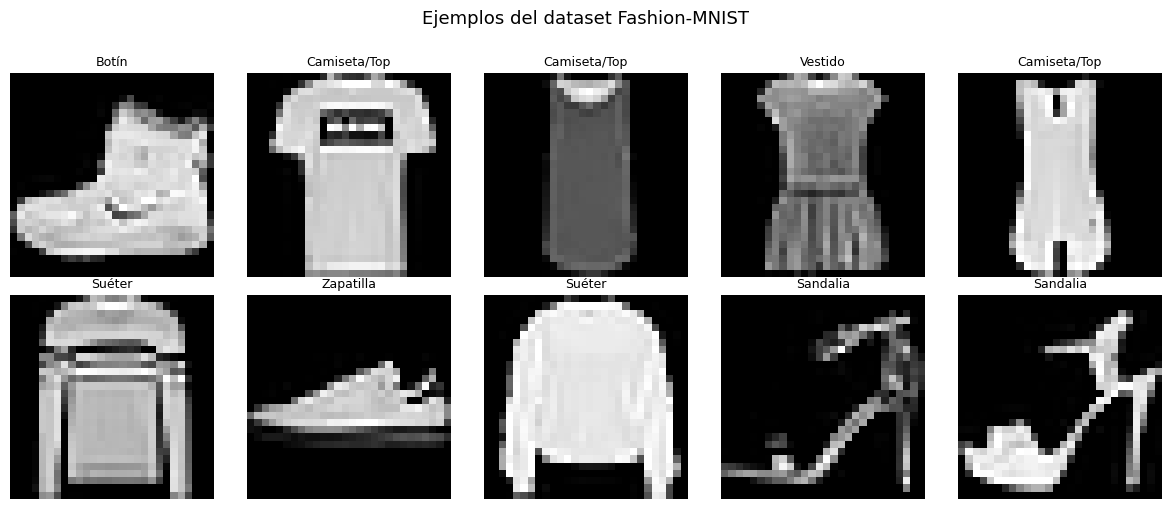

In [3]:
# Visualizamos algunos ejemplos del dataset
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(nombres_clases[y_train[i]], fontsize=9)
    plt.axis('off')
plt.suptitle('Ejemplos del dataset Fashion-MNIST', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [4]:
# Preprocesamiento
# Las imágenes tienen valores entre 0 y 255, las normalizamos a [0, 1]
# Además, Keras espera que las imágenes tengan una dimensión de canal al final

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

# Añadimos la dimensión del canal (escala de grises = 1 canal)
x_train = np.expand_dims(x_train, axis=-1)  # (60000, 28, 28, 1)
x_test  = np.expand_dims(x_test,  axis=-1)  # (10000, 28, 28, 1)

# Convertimos las etiquetas a one-hot encoding
y_train_oh = keras.utils.to_categorical(y_train, 10)
y_test_oh  = keras.utils.to_categorical(y_test, 10)

print("Formas después del preprocesamiento:")
print(f"  x_train: {x_train.shape}")
print(f"  y_train_oh: {y_train_oh.shape}")

Formas después del preprocesamiento:
  x_train: (60000, 28, 28, 1)
  y_train_oh: (60000, 10)


In [5]:
# Construcción del modelo CNN
# Arquitectura sencilla pero efectiva para este dataset

def construir_cnn(input_shape=(28, 28, 1), num_clases=10):
    model = keras.Sequential([
        # Primer bloque convolucional
        layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same',
                      input_shape=input_shape, name='conv1'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Segundo bloque convolucional
        layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same',
                      name='conv2'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Tercer bloque convolucional
        layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same',
                      name='conv3'),
        layers.BatchNormalization(),

        # Aplanado y clasificador final
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_clases, activation='softmax', name='salida')
    ])
    return model


modelo = construir_cnn()
modelo.summary()

C:\Users\kstiv\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,370 (435.04 KB)

 Trainable params: 110,922 (433.29 KB)

 Non-trainable params: 448 (1.75 KB)

In [6]:
# Compilamos el modelo
# Adam es el optimizador, categorical_crossentropy es la función de pérdida

modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Definimos un callback para reducir el learning rate si el val_loss no mejora
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

# Y otro para detener el entrenamiento si no hay mejora
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1
)

print("Modelo compilado y listo para entrenar.")

Modelo compilado y listo para entrenar.


In [7]:
# Entrenamiento
# Usamos un 10% del conjunto de entrenamiento como validación

historial = modelo.fit(
    x_train, y_train_oh,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 30s 33ms/step - accuracy: 0.8226 - loss: 0.5058 - val_accuracy: 0.7960 - val_loss: 0.5369 - learning_rate: 0.0010
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - accuracy: 0.8956 - loss: 0.2945 - val_accuracy: 0.8705 - val_loss: 0.3531 - learning_rate: 0.0010
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9084 - loss: 0.2547 - val_accuracy: 0.8933 - val_loss: 0.2833 - learning_rate: 0.0010
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9174 - loss: 0.2285 - val_accuracy: 0.9003 - val_loss: 0.2778 - learning_rate: 0.0010
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9239 - loss: 0.2088 - val_accuracy: 0.9192 - val_loss: 0.2213 - learning_rate: 0.0010
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9304 - loss: 0.1924 - val_accuracy: 0.9132 - val_loss: 0.2381 - learning_rate: 0.0010
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9357 - l

In [8]:
# Evaluamos en el conjunto de prueba
loss_test, acc_test = modelo.evaluate(x_test, y_test_oh, verbose=0)
print(f"\nResultados en el conjunto de prueba:")
print(f"  Pérdida   : {loss_test:.4f}")
print(f"  Exactitud : {acc_test * 100:.2f}%")


Resultados en el conjunto de prueba:
  Pérdida   : 0.2782
  Exactitud : 92.35%


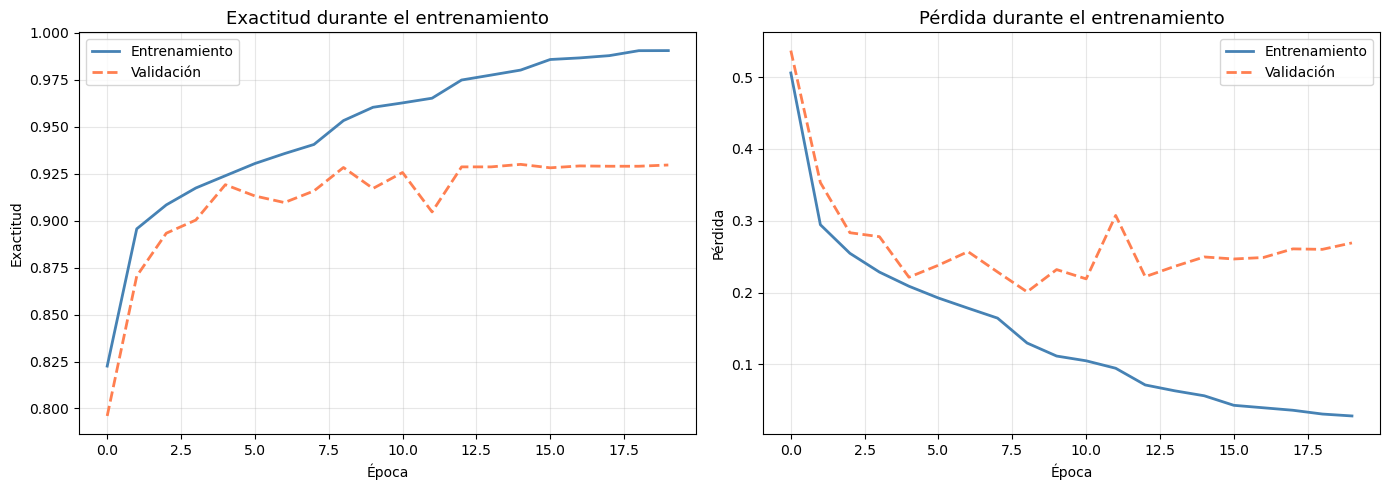

In [9]:
# Visualizamos las curvas de entrenamiento

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Exactitud
ax1.plot(historial.history['accuracy'],     label='Entrenamiento', color='steelblue', lw=2)
ax1.plot(historial.history['val_accuracy'], label='Validación',     color='coral',    lw=2, linestyle='--')
ax1.set_title('Exactitud durante el entrenamiento', fontsize=13)
ax1.set_xlabel('Época')
ax1.set_ylabel('Exactitud')
ax1.legend()
ax1.grid(alpha=0.3)

# Pérdida
ax2.plot(historial.history['loss'],     label='Entrenamiento', color='steelblue', lw=2)
ax2.plot(historial.history['val_loss'], label='Validación',     color='coral',    lw=2, linestyle='--')
ax2.set_title('Pérdida durante el entrenamiento', fontsize=13)
ax2.set_xlabel('Época')
ax2.set_ylabel('Pérdida')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

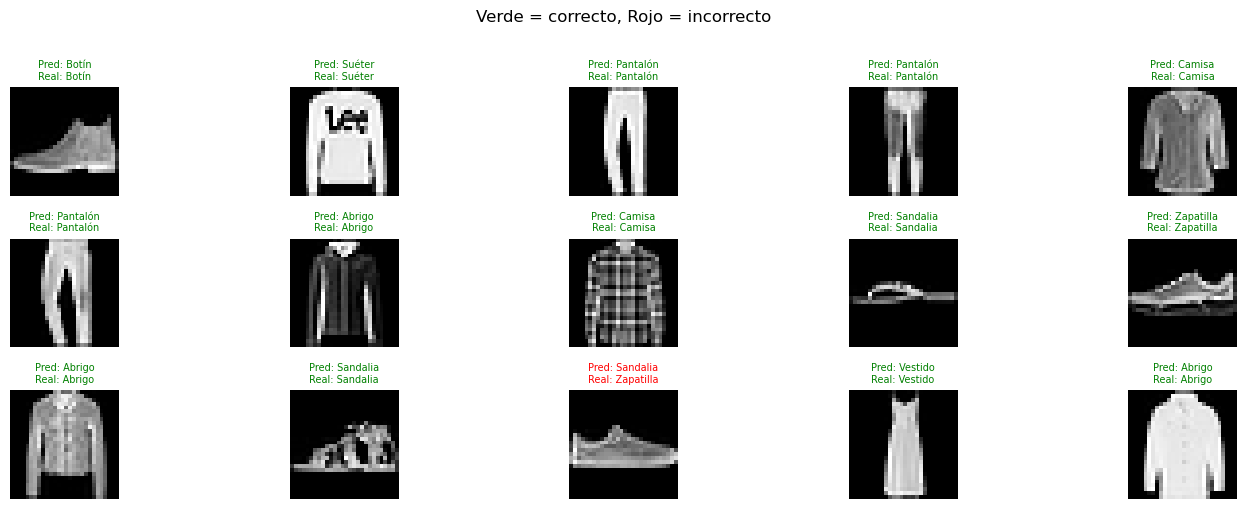

In [10]:
# Visualizamos predicciones sobre algunas imágenes de prueba

predicciones = modelo.predict(x_test[:15], verbose=0)
clases_predichas = np.argmax(predicciones, axis=1)

plt.figure(figsize=(15, 5))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    color = 'green' if clases_predichas[i] == y_test[i] else 'red'
    plt.title(f"Pred: {nombres_clases[clases_predichas[i]]}\nReal: {nombres_clases[y_test[i]]}",
              fontsize=7, color=color)
    plt.axis('off')

plt.suptitle('Verde = correcto, Rojo = incorrecto', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

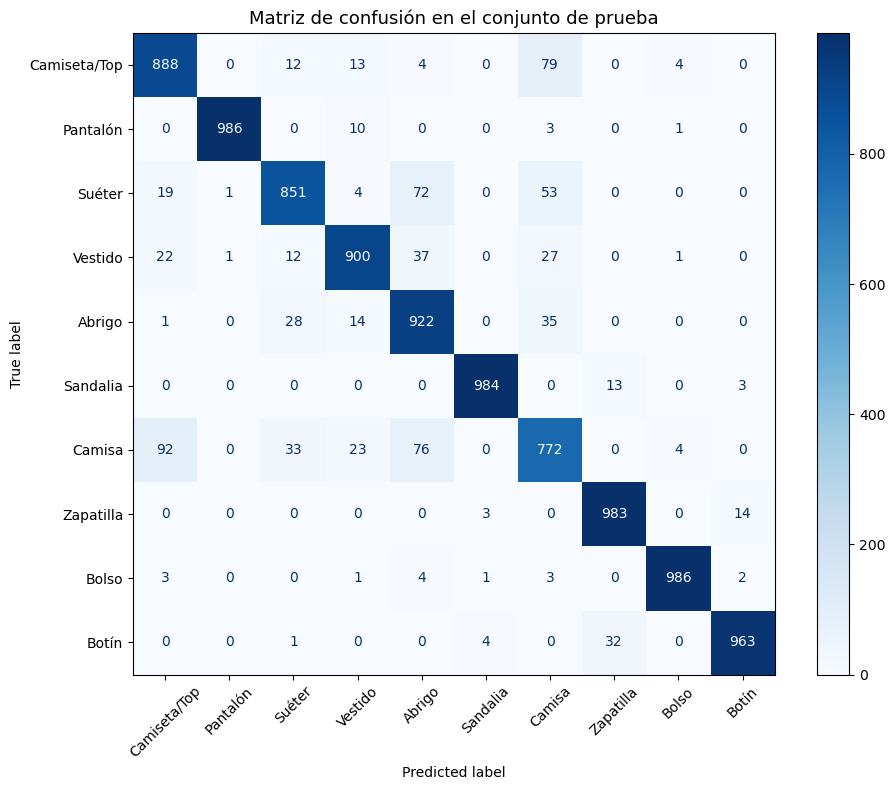


Las celdas más oscuras fuera de la diagonal indican los errores más frecuentes.


In [11]:
# Matriz de confusión para ver en qué categorías se equivoca más la red

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

todas_predicciones = modelo.predict(x_test, verbose=0)
y_pred_clases = np.argmax(todas_predicciones, axis=1)

cm = confusion_matrix(y_test, y_pred_clases)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_clases)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title('Matriz de confusión en el conjunto de prueba', fontsize=13)
plt.tight_layout()
plt.show()

print("\nLas celdas más oscuras fuera de la diagonal indican los errores más frecuentes.")

## 9. Análisis de los resultados

Si todo fue bien, el modelo debería alcanzar una exactitud de entre el 91% y el 93% en el conjunto de prueba, lo cual es bastante decente para una red pequeña entrenada desde cero.

Mirando la matriz de confusión, es normal ver que las mayores confusiones ocurren entre categorías visualmente similares:

- **Camiseta y Camisa:** son bastante parecidas, especialmente en imágenes de 28x28 píxeles en escala de grises.
- **Suéter y Abrigo:** comparten siluetas similares.
- **Zapatilla y Botín:** ambos son zapatos deportivos y pueden ser difíciles de diferenciar con tan poca resolución.

Para mejorar el rendimiento, se podrían probar varias cosas:

- Añadir más capas convolucionales o aumentar el número de filtros.
- Aplicar data augmentation más agresivo.
- Usar una arquitectura preentrenada con transfer learning, aunque para imágenes de 28x28 el beneficio es limitado.
- Entrenar por más épocas con un scheduler de learning rate más sofisticado.

Lo más valioso de este ejercicio no es el porcentaje final, sino haber visto en código real cómo se construye, entrena y evalúa una CNN completa.

## 10. Conclusiones

Las Redes Neuronales Convolucionales representan uno de los avances más importantes en la historia de la inteligencia artificial. Desde sus humildes comienzos con LeNet en los años 90 hasta las arquitecturas masivas de hoy, han transformado industrias enteras y siguen siendo la base de muchos sistemas de visión artificial en producción.

Lo que hace a las CNN tan poderosas no es una idea complicada, sino una combinación elegante de conceptos sencillos: localidad, peso compartido, y jerarquía de características. Estos principios les permiten aprender representaciones visuales útiles con mucha menos información que las redes totalmente conectadas, y de forma que generaliza bien a nuevos datos.

Por supuesto, no son perfectas. El costo computacional, la necesidad de datos y la falta de interpretabilidad son limitaciones reales que los investigadores siguen trabajando para superar. Y el auge de los Vision Transformers plantea preguntas interesantes sobre el futuro del campo.

Pero por ahora, si tienes un problema de visión por computadora, las CNN siguen siendo la primera herramienta que deberías considerar. Son probadas, robustas, y existe un ecosistema enorme de bibliotecas, modelos preentrenados y tutoriales para empezar.



### Referencias recomendadas para seguir aprendiendo

- **Deep Learning** – Ian Goodfellow, Yoshua Bengio y Aaron Courville (libro gratuito online)
- **CS231n: Convolutional Neural Networks for Visual Recognition** – Curso de Stanford (disponible en YouTube)
- **fast.ai** – Curso práctico de deep learning, muy recomendado para aprender haciendo
- **Papers with Code** – Repositorio de artículos con implementaciones abiertas, ideal para ver el estado del arte
- **TensorFlow / Keras Documentation** – Referencia oficial con tutoriales completos
- Artículo original de AlexNet: *"ImageNet Classification with Deep Convolutional Neural Networks"* – Krizhevsky et al., 2012
- Artículo de ResNet: *"Deep Residual Learning for Image Recognition"* – He et al., 2015

GITHUB: https://github.com/Steven-tec/machine-learning-2.git